## Fine-tuning

5 modules, focus on fine-tuning number 3.

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm

from datetime import date
import datetime

import warnings
warnings.filterwarnings("ignore")

In [2]:
# CUDA support 
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')
    
print(device)

cuda:0


In [3]:
# the deep neural network
class MLP(torch.nn.Module):
    def __init__(self, layers, activation="relu", init="xavier"):
        super(MLP, self).__init__()
        
        # parameters
        self.depth = len(layers) - 1
        
        if activation == "relu":
            self.activation = torch.nn.ReLU()
        elif activation == "tanh":
            self.activation = torch.nn.Tanh()
        elif activation == "gelu":
            self.activation = torch.nn.GELU()
        else:
            raise ValueError("Unspecified activation type")
        
        
        layer_list = list()
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation))
            
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        
        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

        if init=="xavier":
            self.xavier_init_weights()
        elif init=="kaiming":
            self.kaiming_init_weights()
    
    def xavier_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Xavier Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.xavier_uniform_(m.weight)
                    m.bias.data.fill_(0.0)

    def kaiming_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Kaiming Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.kaiming_uniform_(m.weight)
                    m.bias.data.fill_(0.0)
                        
    def forward(self, x):
        out = self.layers(x)
        return out
    
class DataGenerator(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = X
        
    def __getitem__(self, index):
        return self.X[index]
    
    def __len__(self):
        return len(self.X)

In [4]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [5]:
data_dir = "./1D-AEMpy/"

print(os.getcwd())

D:\projects\1D-AEMpy\mcl\3_fineTuning-MLP


In [6]:
data_df = pd.read_csv("./../1_trainingData-MLP/COMBINED-erken_rappbode_fallingcreek.csv")
#data_df = data_df.drop(columns=['time'])
data_df
display(data_df.head)

<bound method NDFrame.head of           depth                 time  AirTemp_degC  Longwave_Wm-2  \
0          0.25  2017-06-28 20:00:00     14.284031    -101.205668   
1          0.75  2017-06-28 20:00:00     14.284031    -101.205668   
2          1.25  2017-06-28 20:00:00     14.284031    -101.205668   
3          1.75  2017-06-28 20:00:00     14.284031    -101.205668   
4          2.25  2017-06-28 20:00:00     14.284031    -101.205668   
...         ...                  ...           ...            ...   
11563195   6.75  2023-07-04 14:00:00     23.289200     -70.917406   
11563196   7.25  2023-07-04 14:00:00     23.289200     -70.917406   
11563197   7.75  2023-07-04 14:00:00     23.289200     -70.917406   
11563198   8.25  2023-07-04 14:00:00     23.289200     -70.917406   
11563199   8.75  2023-07-04 14:00:00     23.289200     -70.917406   

          Latent_Wm-2  Sensible_Wm-2  Shortwave_Wm-2  lightExtinct_m-1  \
0          -80.463293      -9.855218       65.608673              0

In [7]:
datetime_list =[datetime.datetime.strptime(date, '%Y-%m-%d %H:%M:%S') for date in data_df['time']]
day_of_year_list = [t.timetuple().tm_yday for t in datetime_list]
time_of_day_list = [t.hour for t in datetime_list]

data_df['day_of_year']=day_of_year_list
data_df['time_of_day']=time_of_day_list

In [8]:
data_df = data_df.drop(columns=['time'])
data_df

,depth,AirTemp_degC,Longwave_Wm-2,Latent_Wm-2,Sensible_Wm-2,Shortwave_Wm-2,lightExtinct_m-1,TKE_Jm-1,ShearStress_Nm-2,Area_m2,...,ice,snow,snowice,Volume_m2,Osgood,MaxDepth_m,MeanDepth_m,obs_temp,day_of_year,time_of_day
0,0.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
1,0.75,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
2,1.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
3,1.75,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.814190,179,20
4,2.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.825920,179,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563195,6.75,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.872310,185,14
11563196,7.25,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.876860,185,14
11563197,7.75,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.867625,185,14
11563198,8.25,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.858390,185,14


In [9]:
for col in data_df.columns:
    print(col)

depth
AirTemp_degC
Longwave_Wm-2
Latent_Wm-2
Sensible_Wm-2
Shortwave_Wm-2
lightExtinct_m-1
TKE_Jm-1
ShearStress_Nm-2
Area_m2
CC
ea
Jlw
Uw
Pa
RH
PP
IceSnowAttCoeff
iceFlag
icemovAvg
density_snow
ice_prior
snow_prior
snowice_prior
rho_snow_prior
IceSnowAttCoeff_prior
iceFlag_prior
dt_iceon_avg_prior
icemovAvg_prior
temp_init00
temp_heat01
temp_ice02
temp_diff03
temp_conv04
temp_mix05
buoyancy
diffusivity
densityGradient
tempChange
ice
snow
snowice
Volume_m2
Osgood
MaxDepth_m
MeanDepth_m
obs_temp
day_of_year
time_of_day


In [10]:
training_frac = 0.60
depth_steps = 50
number_days = len(data_df)#//depth_steps
n_obs = int(number_days*training_frac)#*depth_steps
print(f"Number of days total: {number_days}")
print(f"Number of training points: {n_obs}")

Number of days total: 11563200
Number of training points: 6937920


# Normalizing Data

In [11]:
data = data_df.values

train_data = data[:n_obs]
test_data = data[n_obs:]

#performing normalization on all the columns
scaler = StandardScaler()
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

# Loading Models

## Module 1 HEATING

In [12]:
m1_output_column_ix = [data_df.columns.get_loc(column) for column in ['temp_heat01']]

m1_input_columns = ['depth', 'AirTemp_degC', 'Longwave_Wm-2', 'Latent_Wm-2', 'Sensible_Wm-2', 'Shortwave_Wm-2', 'Uw',
                'lightExtinct_m-1','Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'temp_init00']
m1_output_columns = ['temp_heat01']

m1_input_column_ix = [data_df.columns.get_loc(column) for column in m1_input_columns]
m1_output_column_ix = [data_df.columns.get_loc(column) for column in m1_output_columns]

m1_PATH =  f"./../2_preTraining-MLP/saved_models/heating_model_time.pth"
m1_layers = [len(m1_input_columns), 32, 32, len(m1_output_columns)]

heating_model = MLP(m1_layers, activation="gelu")
m1_checkpoint = torch.load(m1_PATH, map_location=torch.device('cpu'))
heating_model.load_state_dict(m1_checkpoint)
heating_model = heating_model.to(device)

Initializing Network with Xavier Initialization..


## Module 2 ICE+SNOW

In [13]:
m2_input_columns = ['depth', 'AirTemp_degC', 'Longwave_Wm-2', 'Latent_Wm-2', 'Sensible_Wm-2', 'Shortwave_Wm-2',
                'lightExtinct_m-1','Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'PP', 'temp_heat01']
m2_output_columns =['temp_ice02']

m2_input_column_ix = [data_df.columns.get_loc(column) for column in m2_input_columns]
m2_output_column_ix = [data_df.columns.get_loc(column) for column in m2_output_columns]

m2_PATH =  f"./../2_preTraining-MLP/saved_models/ice_model_time.pth"
m2_layers = [len(m2_input_columns), 32, 32, len(m2_output_columns)]

ice_model = MLP(m2_layers, activation="gelu")
m2_checkpoint = torch.load(m2_PATH, map_location=torch.device('cpu'))
ice_model.load_state_dict(m2_checkpoint)
ice_model = ice_model.to(device)

Initializing Network with Xavier Initialization..


## Module 3 DIFFUSION

In [155]:
m3_input_columns = ['depth', 'buoyancy', 'diffusivity', 'lightExtinct_m-1','Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'temp_ice02', 'Uw']
m3_output_columns = ['temp_diff03']

m3_input_column_ix = [data_df.columns.get_loc(column) for column in m3_input_columns]
m3_output_column_ix = [data_df.columns.get_loc(column) for column in m3_output_columns]

m3_PATH =  f"./../2_preTraining-MLP/saved_models/diffusion_model_time.pth"
m3_layers = [len(m3_input_columns), 32, 32, len(m3_output_columns)]

diffusion_model = MLP(m3_layers, activation="gelu")
m3_checkpoint = torch.load(m3_PATH, map_location=torch.device('cpu'))
diffusion_model.load_state_dict(m3_checkpoint)
diffusion_model = diffusion_model.to(device)

Initializing Network with Xavier Initialization..


## Module 4 CONVECTION

In [15]:
m4_input_columns =['depth', 'densityGradient', 'tempChange','Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'temp_diff03', 'Uw']
m4_output_columns =['temp_conv04']

m4_input_column_ix = [data_df.columns.get_loc(column) for column in m4_input_columns]
m4_output_column_ix = [data_df.columns.get_loc(column) for column in m4_output_columns]

m4_PATH =  f"./../2_preTraining-MLP/saved_models/convection_model_time.pth"
m4_layers = [len(m4_input_columns), 32, 32, len(m4_output_columns)]

convection_model = MLP(m4_layers, activation="gelu")
m4_checkpoint = torch.load(m4_PATH, map_location=torch.device('cpu'))
convection_model.load_state_dict(m4_checkpoint)
convection_model = convection_model.to(device)

Initializing Network with Xavier Initialization..


## Module 5 MIXING

In [16]:
m5_input_columns =['depth', 'TKE_Jm-1', 'ShearStress_Nm-2' ,'Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'temp_conv04', 'Uw']
m5_output_columns =['temp_mix05']

m5_input_column_ix = [data_df.columns.get_loc(column) for column in m5_input_columns]
m5_output_column_ix = [data_df.columns.get_loc(column) for column in m5_output_columns]

m5_PATH =  f"./../2_preTraining-MLP/saved_models/mixing_model_time.pth"
m5_layers = [len(m5_input_columns), 32, 32, len(m5_output_columns)]

mixing_model = MLP(m5_layers, activation="gelu")
m5_checkpoint = torch.load(m5_PATH, map_location=torch.device('cpu'))
mixing_model.load_state_dict(m5_checkpoint)
mixing_model = mixing_model.to(device)

Initializing Network with Xavier Initialization..


In [17]:
obs_temp_columns = ['obs_temp']

obs_temp_columns_ix = [data_df.columns.get_loc(column) for column in obs_temp_columns]

In [18]:
# depth_steps = 24
# train_data = np.reshape(train_data, (train_data.shape[0]//depth_steps, depth_steps, train_data.shape[1]))
# test_data = np.reshape(test_data, (test_data.shape[0]//depth_steps, depth_steps, test_data.shape[1]))

In [19]:
#keeping track of the mean and standard deviations
train_mean = scaler.mean_
train_std = scaler.scale_

In [20]:
# Create data set
batch_size = 32#1000

#assert batch_size % 25 ==0, "Batchsize has to be multiple of 25" 

train_dataset = DataGenerator(train_data)
test_dataset = DataGenerator(test_data)
# train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
# test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)

In [21]:
print(train_data.shape)
print(test_data.shape)

(6937920, 49)
(4625280, 49)


In [22]:
def rmse(true, pred):
    return (((true-pred)**2).mean()**0.5).detach().cpu().numpy()

def l2_error(true, pred):
    return np.linalg.norm(pred.detach().cpu().numpy() - true.detach().cpu().numpy()) / np.linalg.norm(true.detach().cpu().numpy()) 

In [23]:
def compute_metrics(model, loader, input_columns, output_columns, train_mean, train_std):
    model.eval()
    y_ = []
    pred_ = []
    mean = torch.tensor(train_mean[output_columns]).to(device)
    std = torch.tensor(train_std[output_columns]).to(device)
    
    for x in iter(loader):
        inputs, target = x[:, input_columns].to(device).float(), x[:, output_columns].to(device).float()
        pred = model(inputs)
        target = target * std + mean
        pred = pred * std + mean
        y_.append(target)
        pred_.append(pred)
    y_ = torch.cat(y_, dim=0) 
    pred_ = torch.cat(pred_, dim=0)
    
    if y_.shape[1]==2:
        rmse_temp = rmse(y_[:,1], pred_[:,1])
        l2_error_temp = l2_error(y_[:,1], pred_[:,1])
    else:
        rmse_temp = rmse(y_[:,0], pred_[:,0])
        l2_error_temp = l2_error(y_[:,0], pred_[:,0])
        
    return rmse_temp, l2_error_temp

In [24]:
def get_rollout_predictions(heating_model, diffusion_model, mixing_model, convection_model, ice_model, loader, plot = True):    
    heating_model.eval()
    diffusion_model.eval()
    mixing_model.eval()
    convection_model.eval()
    ice_model.eval()

    mean = torch.tensor(train_mean[m3_output_column_ix]).float().to(device)
    std = torch.tensor(train_std[m3_output_column_ix]).float().to(device)

#     depthwise_y_pred = []
#     depthwise_y_true = []
    y_ = []
    y_obs_ = []
    pred_ = []
        
    rmse_models = np.zeros((len(loader), 5))
    for ix, x in enumerate(iter(loader)):
        x = x.to(device).float()
        
        m1_input = x[:, m1_input_column_ix]
            
        #model 1
        m1_pred = heating_model(m1_input) #predicts diff and temp
            
        if plot:
            m1_y_true = x[:, m1_output_column_ix[0]] * torch.tensor(train_std[m1_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m1_output_column_ix[0]]).to(device)
            m1_y_pred = m1_pred * torch.tensor(train_std[m1_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m1_output_column_ix[0]]).to(device)

            rmse_models[ix, 0] = rmse(m1_y_true.squeeze(), m1_y_pred.squeeze())

            print("RMSE of after m1", rmse(m1_y_true.flatten(), m1_y_pred.flatten()))

        #model 2
        m2_input = torch.cat([x[:, m2_input_column_ix[:-1]], m1_pred], dim=-1)

        m2_pred = ice_model(m2_input)

        if plot:
            m2_y_true = x[:, m2_output_column_ix[0]] * torch.tensor(train_std[m2_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m2_output_column_ix[0]]).to(device)
            m2_y_pred = m2_pred * torch.tensor(train_std[m2_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m2_output_column_ix[0]]).to(device)

            rmse_models[ix, 1] = rmse(m2_y_true.squeeze(), m2_y_pred.squeeze())

            print("RMSE of after m2", rmse(m2_y_true.flatten(), m2_y_pred.flatten()))


        #model 3
        m3_input = torch.cat([x[:, m3_input_column_ix[:-1]], m2_pred], dim=-1)
        m3_pred = diffusion_model(m3_input)
            
        if plot:
            m3_y_true = x[:, m3_output_column_ix] * torch.tensor(train_std[m3_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m3_output_column_ix[0]]).to(device)
            m3_y_pred = m3_pred * torch.tensor(train_std[m3_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m3_output_column_ix[0]]).to(device)
            rmse_models[ix, 2] = rmse(m3_y_true.squeeze(), m3_y_pred.squeeze())
            print("RMSE of after m3", rmse(m3_y_true.flatten(), m3_y_pred.flatten()))
        
        # model 4

        m4_input = torch.cat([x[:, m4_input_column_ix[:-1]], m3_pred], dim=-1)
        m4_pred = convection_model(m4_input)
            
        if plot:
            m4_y_true = x[:, m4_output_column_ix] * torch.tensor(train_std[m4_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m4_output_column_ix[0]]).to(device)
            m4_y_pred = m4_pred * torch.tensor(train_std[m4_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m4_output_column_ix[0]]).to(device)
            rmse_models[ix, 3] = rmse(m4_y_true.squeeze(), m4_y_pred.squeeze())
            print("RMSE of after m4", rmse(m4_y_true.flatten(), m4_y_pred.flatten()))

        #model 5
        m5_input = torch.cat([x[:, m4_input_column_ix[:-1]], m4_pred], dim=-1)
        m5_pred = mixing_model(m5_input)
            
        if plot:
            m5_y_true = x[:, m5_output_column_ix] * std + mean
            m5_y_pred = m5_pred * std + mean
            rmse_models[ix, 4] = rmse(m5_y_true.squeeze(), m5_y_pred.squeeze())
            print("RMSE of after m5", rmse(m5_y_true.flatten(), m5_y_pred.flatten()))

        y_true = x[:, m5_output_column_ix] * std + mean
        y_obs = x[:, obs_temp_columns_ix] * train_std[obs_temp_columns_ix[0]] + train_mean[obs_temp_columns_ix[0]]
        pred = m5_pred * std + mean
        
        y_.append(y_true)
        y_obs_.append(y_obs)
        pred_.append(pred)

    y_ = torch.cat(y_, dim=0)
    y_obs_ = torch.cat(y_obs_, dim=0)
    pred_ = torch.cat(pred_, dim=0) 
    
    if plot:   
             rmse_models = rmse_models.mean(axis=0)
             plt.figure(figsize=(12,8))
             plt.plot(rmse_models[:, 0], label="RMSE after Heating Model")
             plt.plot(rmse_models[:, 1], label="RMSE after Ice Model")
             plt.plot(rmse_models[:, 2], label="RMSE after Diffusion Model")
             plt.plot(rmse_models[:, 3], label="RMSE after Convection Model")
             plt.plot(rmse_models[:, 4], label="RMSE after Mixing Model")
             plt.legend(loc="upper left", fontsize=12)
             plt.xlabel("Depth", fontsize=12)
             plt.ylabel("RMSE", fontsize=12)
             plt.grid("on", alpha=0.5)
             plt.show()
    
    return pred_, y_, y_obs_, rmse_models


In [25]:
def plot_output(y_pred, y_true, depth_steps, time_label, figsize=(20,10)):
    time_label = np.array([time[:10] for time in time_label])
    time_label = time_label[::depth_steps]
    
    y_pred = y_pred.flatten().detach().cpu().numpy()
    y_true = y_true.flatten().detach().cpu().numpy()
    
    y_true = np.reshape(y_true, (y_true.shape[0]//depth_steps, depth_steps))
    y_pred = np.reshape(y_pred, (y_pred.shape[0]//depth_steps, depth_steps))
    
    N_pts = 6 # number of points to display on the x-label
    
    fig, ax = plt.subplots(3, 1, figsize=figsize)
    sns.heatmap(y_true.T, ax=ax[0], cmap='Spectral_r', vmin=0., vmax=35.)
    ax[0].set_ylabel("Depth", fontsize=15)
    ax[0].set_xlabel("Time", fontsize=15)
    
    xticks_ix = np.array(ax[0].get_xticks()).astype(int)
    time_label = time_label[xticks_ix]
    nelement = len(time_label)//N_pts
    time_label = time_label[::nelement]
    ax[0].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[0].set_xticklabels(time_label, rotation=0)   
#     ax[0].xaxis.set_major_locator(plt.MultipleLocator(100))
    ax[0].collections[0].colorbar.set_label("Actual Temperature")
    
    sns.heatmap(y_pred.T, ax=ax[1], cmap='Spectral_r', vmin=0., vmax=35.)
    ax[1].set_ylabel("Depth", fontsize=15)
    ax[1].set_xlabel("Time", fontsize=15)
    ax[1].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[1].set_xticklabels(time_label, rotation=0)
    ax[1].collections[0].colorbar.set_label("Predicted Temperature")
    
    sns.heatmap(np.abs(y_pred.T-y_true.T), ax=ax[2], cmap='viridis')
    ax[2].set_ylabel("Depth", fontsize=15)
    ax[2].set_xlabel("Time", fontsize=15)
    ax[2].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[2].set_xticklabels(time_label, rotation=0)
    
    ax[2].collections[0].colorbar.set_label("Absolute Error")
    plt.show()

# Rollout Results

## Training Results

In [26]:
train_y_pred, train_y_true, train_y_obs, train_rmse_models = get_rollout_predictions(heating_model, diffusion_model, mixing_model, convection_model, ice_model, train_loader, plot = False)

train_rmse = rmse(train_y_pred.flatten(), train_y_true.flatten())
train_rmse_obs = rmse(train_y_pred.flatten(), train_y_obs.flatten())
train_l2 = l2_error(train_y_pred.flatten(), train_y_true.flatten())

print(f"Train RMSE Simulated: {train_rmse}")
print(f"Train RMSE Observed Temp: {train_rmse_obs}")
print(f"Train L2 Error: {train_l2}")
print(f"The RMSEs after each modelling stage: {train_rmse_models.mean(axis=0)}")



Train RMSE Simulated: 0.373390257358551
Train RMSE Observed Temp: 1.5248397588729858
Train L2 Error: 0.046224623918533325
The RMSEs after each modelling stage: [0. 0. 0. 0. 0.]


In [27]:
print(train_data.shape)
print(test_data.shape)
print(train_y_pred.shape)

(6937920, 49)
(4625280, 49)
torch.Size([6937920, 1])


In [28]:
#plot_output(train_y_pred, train_y_true, depth_steps, train_time, figsize=(20,10))

In [29]:
#plot_output(train_y_pred, train_y_obs, depth_steps, train_time, figsize=(20,10))

## Test Results

In [30]:
test_y_pred, test_y_true, test_y_obs, test_rmse_models = get_rollout_predictions(heating_model, diffusion_model, mixing_model, convection_model, ice_model, test_loader, plot = False)

test_rmse = rmse(test_y_pred.flatten(), test_y_true.flatten())
test_rmse_obs = rmse(test_y_pred.flatten(), test_y_obs.flatten())
test_l2 = l2_error(test_y_pred.flatten(), test_y_true.flatten())

print(f"Test RMSE Simulated: {test_rmse}")
print(f"Test RMSE Observed Temp: {test_rmse_obs}")
print(f"test L2 Error: {test_l2}")
print(f"The RMSEs after each modelling stage: {test_rmse_models.mean(axis=0)}")

Test RMSE Simulated: 0.3396748900413513
Test RMSE Observed Temp: 2.019965171813965
test L2 Error: 0.04258662089705467
The RMSEs after each modelling stage: [0. 0. 0. 0. 0.]


In [31]:
#plot_output(test_y_pred, test_y_true, depth_steps, test_time, figsize=(20,10))

In [32]:
#plot_output(test_y_pred, test_y_obs, depth_steps, test_time, figsize=(20,10))

# Evaluate ALL Models individually

In [33]:
## 1 Heating Model

In [34]:
train_rmse, train_l2_err = compute_metrics( heating_model, train_loader, m1_input_column_ix, m1_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(heating_model, test_loader, m1_input_column_ix, m1_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.017432382945012793, Train L2 Error: 0.002149388088579369
Test RMSE: 0.856970546932288, Train L2 Error: 0.10493775013207154


In [35]:
## 2 Ice Model

In [36]:
train_rmse, train_l2_err = compute_metrics( ice_model, train_loader, m2_input_column_ix, m2_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(ice_model, test_loader, m2_input_column_ix, m2_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.006260270706493421, Train L2 Error: 0.0007718829969873578
Test RMSE: 1.1644438307956946, Train L2 Error: 0.14258857039105396


## 3 Diffusion Model

In [37]:
train_rmse, train_l2_err = compute_metrics( diffusion_model, train_loader, m3_input_column_ix, m3_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(diffusion_model, test_loader, m3_input_column_ix, m3_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.0029962948030720043, Train L2 Error: 0.00036944047860618497
Test RMSE: 0.6249118672838131, Train L2 Error: 0.07652171257014279


## Convection Model

In [38]:
train_rmse, train_l2_err = compute_metrics( convection_model, train_loader, m4_input_column_ix, m4_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(convection_model, test_loader, m4_input_column_ix, m4_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.029252667325510864, Train L2 Error: 0.003607094056056665
Test RMSE: 0.3718779370297769, Train L2 Error: 0.04554201470147616


## Mixing Model

In [39]:
train_rmse, train_l2_err = compute_metrics( mixing_model, train_loader, m5_input_column_ix, m5_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(mixing_model, test_loader, m5_input_column_ix, m5_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.038506612262523804, Train L2 Error: 0.004748024736873181
Test RMSE: 0.2999301662418263, Train L2 Error: 0.036731378120753264


# Finetuning

In [156]:
lr = 1e-5
# decay_rate = 0.1
# decay_steps = 500

params = list(heating_model.parameters())  + list(ice_model.parameters()) + list(diffusion_model.parameters()) + list(convection_model.parameters()) + list(mixing_model.parameters()) 

optimizer = torch.optim.Adam(params, lr=lr, 
                             betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_steps, gamma=decay_rate)

criterion = torch.nn.MSELoss()

# Freeze model weights

In [157]:
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False

def unfreeze_model(model):
    for param in model.parameters():
        param.requires_grad = True

In [158]:
#freeze_model(heating_model)
freeze_model(heating_model)
unfreeze_model(diffusion_model)
freeze_model(convection_model)
freeze_model(ice_model)
freeze_model(mixing_model)


# Finetuning on Observed Temperature

In [160]:
heating_model.train()
diffusion_model.train()
convection_model.train()
ice_model.train()
mixing_model.train()

n_epochs = 100

# mean and standard dev of "temp_total04" of model 4 output
mean_out3 = torch.tensor(train_mean[m5_output_column_ix[0]]).float().to(device)
std_out3 = torch.tensor(train_std[m5_output_column_ix[0]]).float().to(device)

mean_obs = torch.tensor(train_mean[obs_temp_columns_ix[0]]).float().to(device)
std_obs = torch.tensor(train_std[obs_temp_columns_ix[0]]).float().to(device)

# mean and standard dev of "input_temp" of model 1 input
m1_mean = torch.tensor(train_mean[m1_input_column_ix[-1]]).float().to(device)
m1_std = torch.tensor(train_std[m1_input_column_ix[-1]]).float().to(device)

train_loss = []
LOSS_m1 = []
LOSS_m2 = []
LOSS_m3 = []
LOSS_m4 = []
LOSS_m5 = []

for it in tqdm(range(n_epochs)):
    loss_epoch = 0
    loss_epoch_m1 = 0
    loss_epoch_m2 = 0
    loss_epoch_m3 = 0
    loss_epoch_m4 = 0
    loss_epoch_m5 = 0
    for ix, x in enumerate(iter(train_loader)):
        x = x.to(device).float()
        optimizer.zero_grad()
        
      #  m1_input = x[:, m1_input_column_ix]
        m1_input = x[:, m1_input_column_ix]
        
        #model 1
        m1_pred = heating_model(m1_input) #predicts diff and temp
        loss_m1 = criterion(m1_pred, x[:, m1_output_column_ix])

        #model 2
        m2_input = torch.cat([x[:, m2_input_column_ix[:-1]], m1_pred], dim=-1)
        # m1_pred = heat_diff_model(m1_input)
        
        m2_pred = ice_model(m2_input)
        loss_m2 = criterion(m2_pred, x[:, m2_output_column_ix])
        
        #m1_pred = heat_diff_model(m1_input) #predicts diff and temp
        #m1_pred_temp = m1_pred[:,1:2]
            
        #loss_m1 = criterion(m1_pred_temp, x[:, m1_output_column_ix[1]].unsqueeze(1))

        #model 3
        last_vec =  x[:, m3_input_column_ix[-1]]
        m3_input = torch.cat([x[:, m3_input_column_ix[:-2]],  m2_pred, last_vec.unsqueeze(1)], dim=-1)
        m3_pred = diffusion_model(m3_input)

        loss_m3 = criterion(m3_pred, x[:, m3_output_column_ix])
        
        #model 4
        last_vec =  x[:, m4_input_column_ix[-1]]
        m4_input = torch.cat([x[:, m4_input_column_ix[:-2]], m3_pred, last_vec.unsqueeze(1)], dim=-1)
        m4_pred = convection_model(m4_input)

        loss_m4 = criterion(m4_pred, x[:, m4_output_column_ix])

        #model 5
        last_vec =  x[:, m5_input_column_ix[-1]]
        m5_input = torch.cat([x[:, m5_input_column_ix[:-2]], m4_pred, last_vec.unsqueeze(1)], dim=-1)
        m5_pred = mixing_model(m5_input)
        
        obs_temp_true = x[:, obs_temp_columns_ix] * std_obs + mean_obs
        obs_temp_true_norm = (obs_temp_true - mean_out3)/std_out3
        
        loss_m5 = criterion(m5_pred, obs_temp_true_norm)
        
        

        #loss = (loss_m0 + loss_m1 + loss_m2 + loss_m3 + loss_m4)
        
        loss = loss_m5
        
        loss.backward()
        optimizer.step()
        
        loss_epoch += loss.item()
        loss_epoch_m1 += loss_m1.item()
        loss_epoch_m2 += loss_m2.item()
        loss_epoch_m3 += loss_m3.item()
        loss_epoch_m4 += loss_m4.item()
        loss_epoch_m5 += loss_m5.item()
    
    loss_epoch = loss_epoch/len(train_loader)
    
    loss_epoch_m1 = loss_epoch_m1/len(train_loader)
    loss_epoch_m2 = loss_epoch_m2/len(train_loader)
    loss_epoch_m3 = loss_epoch_m3/len(train_loader)
    loss_epoch_m4 = loss_epoch_m4/len(train_loader)
    loss_epoch_m5 = loss_epoch_m5/len(train_loader)
    
    train_loss.append(loss_epoch)
    LOSS_m1.append(loss_epoch_m1)
    LOSS_m2.append(loss_epoch_m2)
    LOSS_m3.append(loss_epoch_m3)
    LOSS_m4.append(loss_epoch_m4)
    LOSS_m5.append(loss_epoch_m5)
    if it % 1 == 0:
        print(f"Epoch : {it}, Train_loss: {train_loss[-1]}, Loss m1: {LOSS_m1[-1]}, Loss m2: {LOSS_m2[-1]},  Loss m3: {LOSS_m3[-1]}, Loss m4: {LOSS_m4[-1]}, Loss m5: {LOSS_m5[-1]}")
        
    if it % 10 == 0:
        print(rmse(obs_temp_true_norm.squeeze(), m5_pred.squeeze()))
    
    #plot the loss_m1, m2


  1%|          | 1/100 [16:37<27:26:31, 997.90s/it]

Epoch : 0, Train_loss: 0.04633529100875281, Loss m1: 1.309569865833671e-05, Loss m2: 1.4561401432802872e-05,  Loss m3: 0.052571035348227046, Loss m4: 0.049285861072673416, Loss m5: 0.04633529100875281
0.03170134


  2%|▏         | 2/100 [33:15<27:09:32, 997.68s/it]

Epoch : 1, Train_loss: 0.05361950019480576, Loss m1: 1.309569865833671e-05, Loss m2: 1.4561401432802872e-05,  Loss m3: 0.06941816471817705, Loss m4: 0.06519853092803651, Loss m5: 0.05361950019480576


  3%|▎         | 3/100 [49:53<26:53:00, 997.74s/it]

...

Epoch : 97, Train_loss: 0.02093320269245254, Loss m1: 1.309569865833671e-05, Loss m2: 1.4561401432802872e-05,  Loss m3: 0.10888234304111975, Loss m4: 0.1002297284321278, Loss m5: 0.02093320269245254


 99%|█████████▉| 99/100 [27:29:37<16:40, 1000.92s/it]

Epoch : 98, Train_loss: 0.021909962210005542, Loss m1: 1.309569865833671e-05, Loss m2: 1.4561401432802872e-05,  Loss m3: 0.11327780934086262, Loss m4: 0.10371892240806103, Loss m5: 0.021909962210005542


100%|██████████| 100/100 [27:46:17<00:00, 999.78s/it] 

Epoch : 99, Train_loss: 0.02602413794806623, Loss m1: 1.309569865833671e-05, Loss m2: 1.4561401432802872e-05,  Loss m3: 0.12445843621331718, Loss m4: 0.1122884569654847, Loss m5: 0.02602413794806623


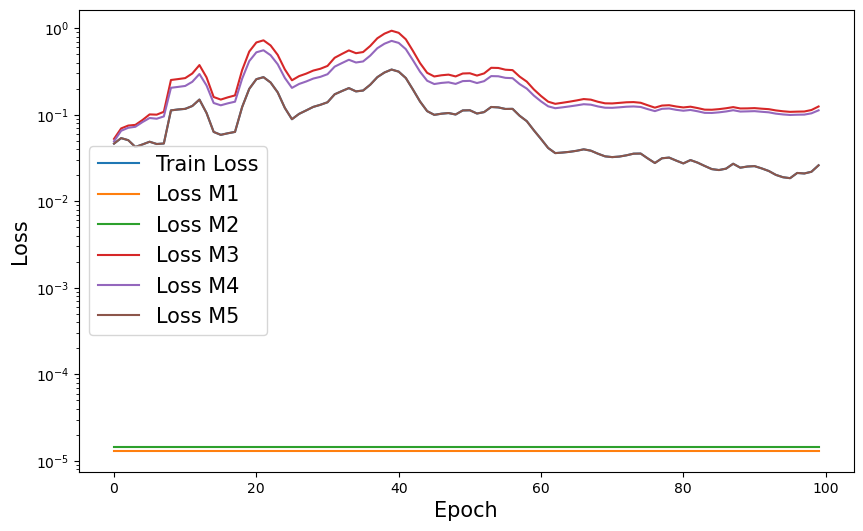

In [163]:
plt.figure(figsize=(10,6))
plt.plot(train_loss, label = "Train Loss")
plt.plot(LOSS_m1, label = "Loss M1")
plt.plot(LOSS_m2, label = "Loss M2")
#plt.plot(LOSS_m2, label = "Loss M2")
plt.plot(LOSS_m3, label = "Loss M3")
plt.plot(LOSS_m4, label = "Loss M4")
plt.plot(LOSS_m5, label = "Loss M5")
plt.ylabel("Loss", fontsize=15)
plt.xlabel("Epoch", fontsize=15)
plt.yscale("log")
plt.legend(fontsize=15)
plt.show()

# Rollout Evaluation After FineTuning

In [164]:
train_y_pred, train_y_true, train_y_obs, train_rmse_models = get_rollout_predictions(heating_model, diffusion_model, mixing_model, convection_model, ice_model, train_loader, plot = False)

train_rmse = rmse(train_y_pred.flatten(), train_y_true.flatten())
train_rmse_obs = rmse(train_y_pred.flatten(), train_y_obs.flatten())
train_l2 = l2_error(train_y_pred.flatten(), train_y_true.flatten())

print(f"Train RMSE Simulated: {train_rmse}")
print(f"Train RMSE Observed Temp: {train_rmse_obs}")
print(f"Train L2 Error: {train_l2}")
print(f"The RMSEs after each modelling stage: {train_rmse_models.mean(axis=0)}")

Train RMSE Simulated: 0.37339380383491516
Train RMSE Observed Temp: 1.524840235710144
Train L2 Error: 0.046225082129240036
The RMSEs after each modelling stage: [0. 0. 0. 0. 0.]


In [124]:
#plot_output(train_y_pred, train_y_true, depth_steps, train_time, figsize=(20,10))

In [125]:
#plot_output(train_y_pred, train_y_obs, depth_steps, train_time, figsize=(20,10))

In [165]:
test_y_pred, test_y_true, test_y_obs, test_rmse_models = get_rollout_predictions(heating_model, diffusion_model, mixing_model, convection_model, ice_model, test_loader, plot = False)

test_rmse = rmse(test_y_pred.flatten(), test_y_true.flatten())
test_rmse_obs = rmse(test_y_pred.flatten(), test_y_obs.flatten())
test_l2 = l2_error(test_y_pred.flatten(), test_y_true.flatten())

print(f"Test RMSE Simulated: {test_rmse}")
print(f"Test RMSE Observed Temp: {test_rmse_obs}")
print(f"test L2 Error: {test_l2}")
print(f"The RMSEs after each modelling stage: {test_rmse_models.mean(axis=0)}")

Test RMSE Simulated: 0.3395453095436096
Test RMSE Observed Temp: 2.019805908203125
test L2 Error: 0.04257175698876381
The RMSEs after each modelling stage: [0. 0. 0. 0. 0.]


In [127]:
#plot_output(test_y_pred, test_y_true, depth_steps, test_time, figsize=(20,10))

In [128]:
#plot_output(test_y_pred, test_y_obs, depth_steps, test_time, figsize=(20,10))

# Evaluate ALL Models individually

## HEATING FINE-TUNED

In [129]:
train_rmse, train_l2_err = compute_metrics( heating_model, train_loader, m1_input_column_ix, m1_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(heating_model, test_loader, m1_input_column_ix, m1_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.017432382945012793, Train L2 Error: 0.002149388088579369
Test RMSE: 0.856970546932288, Train L2 Error: 0.10493775013207154


In [130]:
## ICE FINE-TUNED

In [131]:
train_rmse, train_l2_err = compute_metrics( ice_model, train_loader, m2_input_column_ix, m2_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(ice_model, test_loader, m2_input_column_ix, m2_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.006260270706493421, Train L2 Error: 0.0007718829969873578
Test RMSE: 1.1644438307956946, Train L2 Error: 0.14258857039105396


In [132]:
## DIFFUSION FINE-TUNED

In [166]:
train_rmse, train_l2_err = compute_metrics( diffusion_model, train_loader, m3_input_column_ix, m3_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(diffusion_model, test_loader, m3_input_column_ix, m3_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 2.2628715990896753, Train L2 Error: 0.27901005125894607
Test RMSE: 19.906609839889356, Train L2 Error: 2.4376043345679763


In [134]:
## CONVECTION FINE-TUNED

In [135]:
train_rmse, train_l2_err = compute_metrics( convection_model, train_loader, m4_input_column_ix, m4_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(convection_model, test_loader, m4_input_column_ix, m4_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.029252667325510864, Train L2 Error: 0.003607094056056665
Test RMSE: 0.3718779370297769, Train L2 Error: 0.04554201470147616


In [136]:
## MIXING FINE-TUNED

In [137]:
train_rmse, train_l2_err = compute_metrics( mixing_model, train_loader, m5_input_column_ix, m5_output_column_ix, train_mean, train_std)
print(f"Train RMSE: {train_rmse}, Train L2 Error: {train_l2_err}")

test_rmse, test_l2_err = compute_metrics(mixing_model, test_loader, m5_input_column_ix, m5_output_column_ix, train_mean, train_std)
print(f"Test RMSE: {test_rmse}, Train L2 Error: {test_l2_err}")

Train RMSE: 0.038506612262523804, Train L2 Error: 0.004748024736873181
Test RMSE: 0.2999301662418263, Train L2 Error: 0.036731378120753264


# Compute Model Similarity after Finetuning

In [138]:
def compute_model_similarity(model1, model2):
    weight1 = []
    weight2 = []
    for param1, param2 in zip(model1.parameters(), model2.parameters()):
        weight1.append(param1.detach().clone().flatten())
        weight2.append(param2.detach().clone().flatten())
    weight1 = torch.cat(weight1, dim=0)
    weight2 = torch.cat(weight2, dim=0)
    
    #Cosine Similarity
    cos = nn.CosineSimilarity(dim=0, eps=1e-8)
    cos_sim = cos(weight1, weight2)
    
    #L2 norm
    l2 = torch.norm((weight1-weight2), p='fro', dim=0)
    
    return cos_sim, l2

In [139]:
heating_model_init = MLP(m1_layers, activation="gelu")
heating_model_init.load_state_dict(m1_checkpoint)
heating_model_init = heating_model_init.to(device)

cos_sim, l2_dist = compute_model_similarity(heating_model_init, heating_model)

print(f"Cosine Similarity: {cos_sim}")
print(f"L2 Norm: {l2_dist}")

Initializing Network with Xavier Initialization..
Cosine Similarity: 0.9999998807907104
L2 Norm: 0.0


In [140]:
ice_model_init = MLP(m2_layers, activation="gelu")
ice_model_init.load_state_dict(m2_checkpoint)
ice_model_init = ice_model_init.to(device)

cos_sim, l2_dist = compute_model_similarity(ice_model_init, ice_model)

print(f"Cosine Similarity: {cos_sim}")
print(f"L2 Norm: {l2_dist}")

Initializing Network with Xavier Initialization..
Cosine Similarity: 0.9999998807907104
L2 Norm: 0.0


In [141]:
diffusion_model_init = MLP(m3_layers, activation="gelu")
diffusion_model_init.load_state_dict(m3_checkpoint)
diffusion_model_init = diffusion_model_init.to(device)

cos_sim, l2_dist = compute_model_similarity(diffusion_model_init, diffusion_model)

print(f"Cosine Similarity: {cos_sim}")
print(f"L2 Norm: {l2_dist}")

Initializing Network with Xavier Initialization..
Cosine Similarity: 0.7580616474151611
L2 Norm: 37.24519348144531


In [142]:
convection_model_init = MLP(m4_layers, activation="gelu")
convection_model_init.load_state_dict(m4_checkpoint)
convection_model_init = convection_model_init.to(device)

cos_sim, l2_dist = compute_model_similarity(convection_model_init, convection_model)

print(f"Cosine Similarity: {cos_sim}")
print(f"L2 Norm: {l2_dist}")

Initializing Network with Xavier Initialization..
Cosine Similarity: 1.0
L2 Norm: 0.0


In [143]:
mixing_model_init = MLP(m5_layers, activation="gelu")
mixing_model_init.load_state_dict(m5_checkpoint)
mixing_model_init = mixing_model_init.to(device)

cos_sim, l2_dist = compute_model_similarity(mixing_model_init, mixing_model)

print(f"Cosine Similarity: {cos_sim}")
print(f"L2 Norm: {l2_dist}")

Initializing Network with Xavier Initialization..
Cosine Similarity: 1.0
L2 Norm: 0.0


In [144]:
# Freeze all models again and compute finetuned diffusivity values

In [145]:
# Unfreeze diffusion model and finetune it on projected diffusivities

In [146]:
PATH = f"./saved_models/diffusion_model_finetuned.pth"
torch.save(diffusion_model.state_dict(), PATH)

In [147]:
def plot_output_freeLimits(y_pred, y_true, depth_steps, time_label, figsize=(20,10)):
    time_label = np.array([time[:10] for time in time_label])
    time_label = time_label[::depth_steps]
    
    y_pred = y_pred.flatten().detach().cpu().numpy()
    y_true = y_true.flatten().detach().cpu().numpy()
    
    y_true = np.reshape(y_true, (y_true.shape[0]//depth_steps, depth_steps))
    y_pred = np.reshape(y_pred, (y_pred.shape[0]//depth_steps, depth_steps))
    
    N_pts = 6 # number of points to display on the x-label
    
    fig, ax = plt.subplots(3, 1, figsize=figsize)
    sns.heatmap(y_true.T, ax=ax[0], cmap='Spectral_r')
    ax[0].set_ylabel("Depth", fontsize=15)
    ax[0].set_xlabel("Time", fontsize=15)
    
    xticks_ix = np.array(ax[0].get_xticks()).astype(int)
    time_label = time_label[xticks_ix]
    nelement = len(time_label)//N_pts
    time_label = time_label[::nelement]
    ax[0].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[0].set_xticklabels(time_label, rotation=0)   
#     ax[0].xaxis.set_major_locator(plt.MultipleLocator(100))
    ax[0].collections[0].colorbar.set_label("Actual Temperature")
    
    sns.heatmap(y_pred.T, ax=ax[1], cmap='Spectral_r')
    ax[1].set_ylabel("Depth", fontsize=15)
    ax[1].set_xlabel("Time", fontsize=15)
    ax[1].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[1].set_xticklabels(time_label, rotation=0)
    ax[1].collections[0].colorbar.set_label("Predicted Temperature")
    
    sns.heatmap(np.abs(y_pred.T-y_true.T), ax=ax[2], cmap='viridis')
    ax[2].set_ylabel("Depth", fontsize=15)
    ax[2].set_xlabel("Time", fontsize=15)
    ax[2].xaxis.set_major_locator(plt.MaxNLocator(N_pts))
    ax[2].set_xticklabels(time_label, rotation=0)
    
    ax[2].collections[0].colorbar.set_label("Absolute Error")
    plt.show()

In [70]:
#plot_output_freeLimits(train_y_pred, train_y_obs, depth_steps, train_time, figsize=(20,10))

In [71]:
#plot_output_freeLimits(test_y_pred, test_y_obs, depth_steps, test_time, figsize=(20,10))